In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import sys
import json
import torch

from util.config_utils import load_yaml
from util.metrics import analyze_preds, load_preds

import warnings
warnings.filterwarnings('ignore')

/home/muyang/miniconda3/envs/ilp/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
run_name = 'verbnoun_fuchsia-monument'
test_run_name = 'ramp-10'

target_classes = rarest_k_indices

cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
preds = load_preds(cfg, run_name, test_run_name, preds='neural')
analyze_preds(cfg, run_name, test_run_name, preds=preds, target_classes=target_classes)
preds = load_preds(cfg, run_name, test_run_name, preds='rules')
analyze_preds(cfg, run_name, test_run_name, preds=preds, target_classes=target_classes)
preds = load_preds(cfg, run_name, test_run_name, preds='joint_v1')
analyze_preds(cfg, run_name, test_run_name, preds=preds, target_classes=target_classes)
preds = load_preds(cfg, run_name, test_run_name, preds='joint_v2')
analyze_preds(cfg, run_name, test_run_name, preds=preds, target_classes=target_classes)

Top1 Accuracy(%)          0.2085
Balanced Accuracy(%)      0.1700
Top3 Accuracy(%)          0.4812
Top5 Accuracy(%)          0.6256
Macro Precision(%)        0.0865
F1 Score(%)               0.0725
Macro Recall(%)           0.0850
Top1 Accuracy(%)          0.1329
Balanced Accuracy(%)      0.1679
Top3 Accuracy(%)          0.3712
Top5 Accuracy(%)          0.5809
Macro Precision(%)        0.0582
F1 Score(%)               0.0522
Macro Recall(%)           0.0840
Top1 Accuracy(%)          0.2094
Balanced Accuracy(%)      0.2172
Top3 Accuracy(%)          0.5276
Top5 Accuracy(%)          0.7115
Macro Precision(%)        0.1018
F1 Score(%)               0.0854
Macro Recall(%)           0.1086
Top1 Accuracy(%)          0.2321
Balanced Accuracy(%)      0.1865
Top3 Accuracy(%)          0.5706
Top5 Accuracy(%)          0.7568
Macro Precision(%)        0.0974
F1 Score(%)               0.0792
Macro Recall(%)           0.0933


{'Top1 Accuracy(%)': 0.23205882352941176,
 'Balanced Accuracy(%)': np.float64(0.18652949277594122),
 'Top3 Accuracy(%)': np.float64(0.5705882352941176),
 'Top5 Accuracy(%)': np.float64(0.7567647058823529),
 'Macro Precision(%)': np.float64(0.0974273596821194),
 'F1 Score(%)': np.float64(0.07920871269266228),
 'Macro Recall(%)': np.float64(0.0932647463879706)}

In [3]:
def plot_metrics(paths):
    neural_metrics = []
    rules_metrics = []
    joint_metrics = []
    
    # Define font sizes
    TITLE_SIZE = 14
    AXIS_LABEL_SIZE = 12
    TICK_SIZE = 10
    LEGEND_SIZE = 10

    for run_name, test_run_name in paths:
        cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
        neural_metrics.append(analyze_preds(cfg, run_name, test_run_name, preds='neural', do_print=True))
        rules_metrics.append(analyze_preds(cfg, run_name, test_run_name, preds='rules', do_print=True))
        joint_metrics.append(analyze_preds(cfg, run_name, test_run_name, preds='joint', do_print=True))


    # Assuming analyze_preds returns a dictionary of metrics
    metric_names = neural_metrics[0].keys()

    # Plotting
    num_metrics = len(metric_names)
    fig, axes = plt.subplots(num_metrics, 1, figsize=(12, 4 * num_metrics), sharex=True)

    for i, metric in enumerate(metric_names):
        neural_values = [metrics[metric] for metrics in neural_metrics]
        rules_values = [metrics[metric] for metrics in rules_metrics]
        joint_values = [metrics[metric] for metrics in joint_metrics]
        
        axes[i].plot(range(len(paths)), neural_values, label='Neural', marker='o')
        axes[i].plot(range(len(paths)), rules_values, label='Rules', marker='o')
        axes[i].plot(range(len(paths)), joint_values, label='Joint', marker='o')
        
        axes[i].set_title(f'{metric} over Different Runs', fontsize=TITLE_SIZE)
        axes[i].set_ylabel(metric, fontsize=AXIS_LABEL_SIZE)
        axes[i].legend(fontsize=LEGEND_SIZE)
        axes[i].tick_params(axis='both', labelsize=TICK_SIZE)
    
    axes[-1].set_xlabel('Run Index', fontsize=AXIS_LABEL_SIZE)
    axes[-1].set_xticks(ticks=range(len(paths)))
    axes[-1].set_xticklabels([run[0] for run in paths], rotation=45, fontsize=TICK_SIZE)
    
    plt.tight_layout()
    plt.show()

def compare_all_paths(paths_dict):
    """
    Plot metrics for different path sets on the same graph for comparison.
    
    Args:
        paths_dict: Dictionary mapping path set names to path lists
                    e.g., {'test_5': test_5_paths, 'test_10': test_10_paths}
    """
    # Define font sizes
    TITLE_SIZE = 20
    AXIS_LABEL_SIZE = 18
    TICK_SIZE = 16
    LEGEND_SIZE = 15
    
    # Get all metrics from the first path set to determine what to plot
    sample_path_set = list(paths_dict.values())[0]
    sample_run_name, sample_test_run_name = sample_path_set[0]
    sample_cfg = load_yaml(os.path.join('runs/', sample_run_name, 'test_runs', sample_test_run_name, 'config.yaml'))
    sample_metrics = analyze_preds(sample_cfg, sample_run_name, sample_test_run_name, preds='neural', do_print=False)
    metric_names = sample_metrics.keys()
    
    # Get a reference path set for neural and rules models
    reference_paths = list(paths_dict.values())[0]
    
    # Create a figure with subplots arranged in two columns
    num_metrics = len(metric_names)
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    #fig.suptitle(f'Metrics Comparison Across Different Test Sets', fontsize=16)
    
    # Flatten axes array for easier indexing
    axes = axes.flatten() if num_metrics > 1 else [axes]
    
    weights = {
        'test_1': 1, 
        'test_5': 5, 
        'test_20': 20,
    }
    joint_markers = {
        'test_1': 'D',  # diamond
        'test_5': 'v',  # pentagon
        'test_20': '^', # triangle
    }
    
    for i, metric in enumerate(metric_names):
        
        # Plot neural model
        x_values = [int(run_name.split('_')[0]) for run_name, _ in reference_paths]
        neural_values = []
        for run_name, test_run_name in reference_paths:
            cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
            metrics = analyze_preds(cfg, run_name, test_run_name, preds='neural', do_print=False)
            # Convert to percentage for appropriate metrics
            if "Entropy" not in metric:
                neural_values.append(metrics[metric] * 100)
            else:
                neural_values.append(metrics[metric])
        axes[i].plot(x_values, neural_values, linestyle='--', marker='o', label="Neural")
        
        # Plot rules model
        rules_values = []
        for run_name, test_run_name in reference_paths:
            cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
            metrics = analyze_preds(cfg, run_name, test_run_name, preds='rules', do_print=False)
            # Convert to percentage for appropriate metrics
            if "Entropy" not in metric:
                rules_values.append(metrics[metric] * 100)
            else:
                rules_values.append(metrics[metric])
        axes[i].plot(x_values, rules_values, linestyle='--', marker='s', label="Rules")
        
        axes[i].set_title(f'{metric}', fontsize=TITLE_SIZE)
        #axes[i].set_ylabel(metric)
        axes[i].set_xlabel('Size of training set', fontsize=AXIS_LABEL_SIZE)
        axes[i].grid(True, linestyle='--', alpha=0.7)
        axes[i].tick_params(axis='both', labelsize=TICK_SIZE)
        
        # Plot joint model for each path set first
        for path_name, paths in reversed(paths_dict.items()):
            x_values = [int(run_name.split('_')[0]) for run_name, _ in paths]
            joint_values = []
            
            for run_name, test_run_name in paths:
                cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
                metrics = analyze_preds(cfg, run_name, test_run_name, preds='joint', do_print=False)
                # Convert to percentage for appropriate metrics
                if "Entropy" not in metric:
                    joint_values.append(metrics[metric] * 100)
                else:
                    joint_values.append(metrics[metric])
            
            axes[i].plot(x_values, joint_values, linestyle='-', marker=joint_markers[path_name], 
                         linewidth=1, label=f"Joint@{weights[path_name]}")
        
        # Only show legend for the first subplot to avoid clutter
        if i == 1 :
            axes[i].legend(['Neural only', 'Rules only', 'LeaPR@20', 'LeaPR@5', 'LeaPR@1'], fontsize=LEGEND_SIZE)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


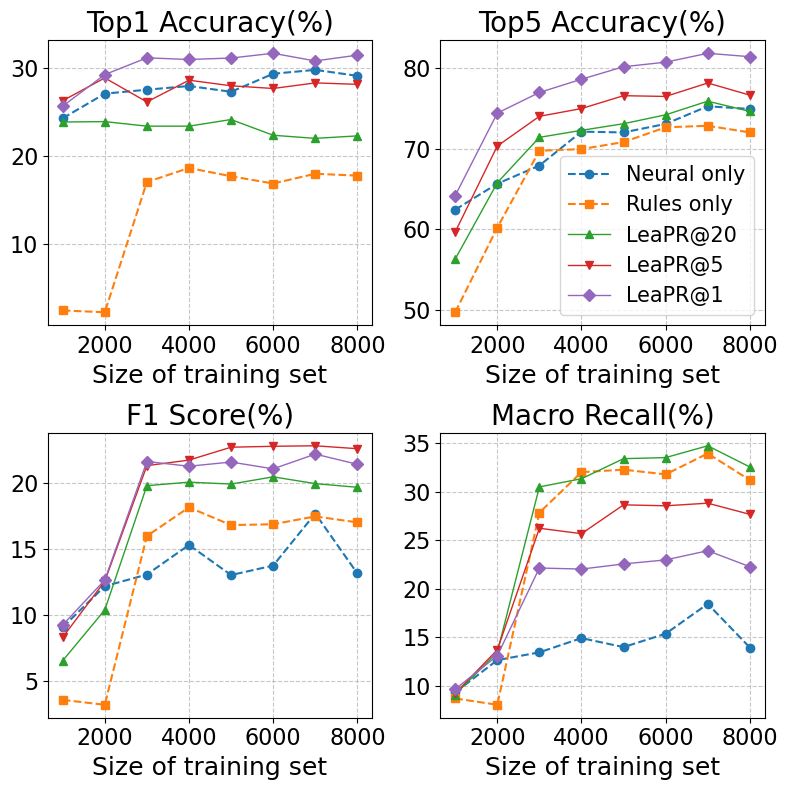

In [5]:
paths_dict = {
    'test_1': test_1_paths_mvit,
    #'test_2': test_2_paths,
    'test_5': test_5_paths_mvit,
    #'test_10': test_10_paths,
    'test_20': test_20_paths_mvit
}
compare_all_paths(paths_dict)

In [11]:
import os
from util.config_utils import load_yaml
from data.ag.action_genome import SingleAG
from torch.utils.data import DataLoader

#cfg = load_yaml(os.path.join('runs/', 'verbnoun_quick-architecture', 'config.yaml'))
train_run_name = 'verbnoun_fuchsia-monument'
test_run_name = 'buffet'
cfg = load_yaml(os.path.join('runs/', train_run_name, 'config.yaml'))
cfg.test.data_split = 'test'
dataset = SingleAG(cfg, split=cfg.test.data_split)
#loader = DataLoader(dataset, batch_size=128, collate_fn=dataset.pred_collate, num_workers=16, shuffle=False)

truth_np = np.array(dataset.truth_values)

Loading dataset from cache: data/ag/cache/test_-1_aa93f8809d10d4dfc487662c5fccc648.pkl


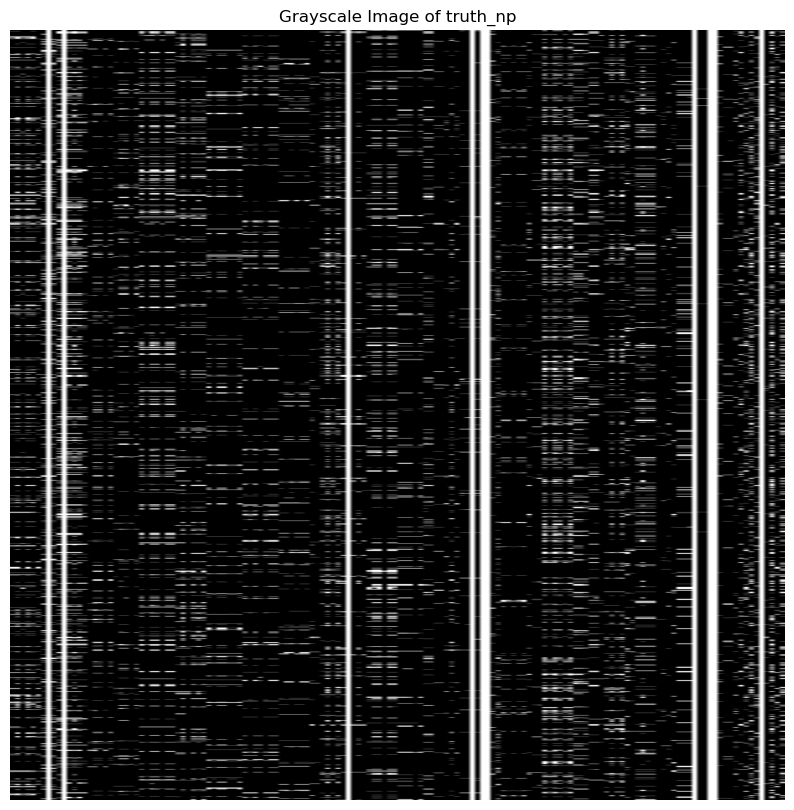

In [12]:
plt.figure(figsize=(10, 10))
plt.imshow(truth_np, cmap='gray', aspect='auto')
plt.title('Grayscale Image of truth_np')
plt.axis('off')  # Hide the axis
plt.show()


113


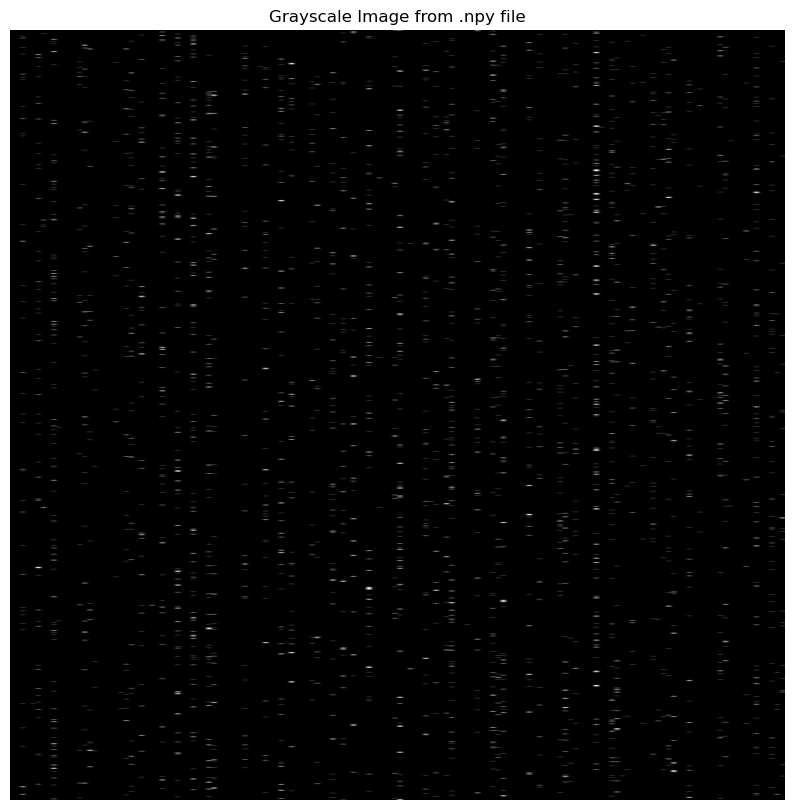

In [14]:
# Load the .npy file
npy_file_path = os.path.join('runs', train_run_name, 'test_runs', test_run_name, 'rules.npy')
#npy_file_path = 'runs/verbnoun_quick-architecture/test_runs/meridian/neural.npy'  # Replace with your actual file path
#npy_file_path = 'runs/verbnoun_quick-architecture/test_runs/meridian/joint.npy'  # Replace with your actual file path

#image_data = np.load(npy_file_path)[:, 1, :] # labels
image_data = np.load(npy_file_path)[:, 0, :] # predictions

max_pred = np.zeros_like(image_data)
max_pred[np.arange(image_data.shape[0]), np.argmax(image_data, axis=1)] = 1


max_idx = np.argmax(image_data, axis=1)
most_common_idx = np.bincount(max_idx).argmax()
print(most_common_idx)

# Visualize the data as a big grayscale image
plt.figure(figsize=(10, 10))
plt.imshow(max_pred, cmap='gray', aspect='auto')
plt.title('Grayscale Image from .npy file')
plt.axis('off')  # Hide the axis
plt.show()


num_classes 150


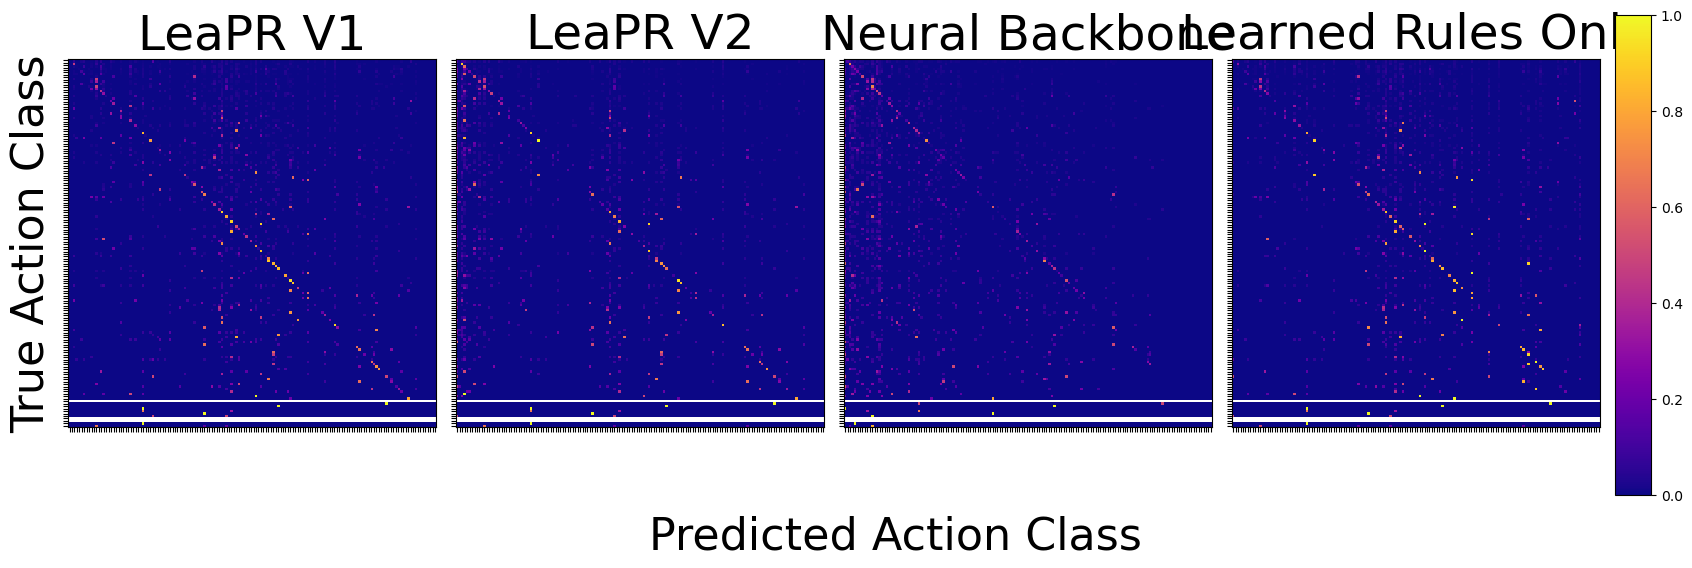

Joint_v1 Model Accuracy: 0.1726
Joint_v2 Model Accuracy: 0.2061
Neural Model Accuracy: 0.1843
Rules Model Accuracy: 0.1548
Joint_v1 Model Accuracy (Last 80 Classes): 0.2570
Joint_v2 Model Accuracy (Last 80 Classes): 0.1917
Neural Model Accuracy (Last 80 Classes): 0.0953
Rules Model Accuracy (Last 80 Classes): 0.2352


: 

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from mpl_toolkits.axes_grid1 import make_axes_locatable

def load_configuration(run_name, test_run_name):
    return load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))

def load_predictions(cfg, run_name, test_run_name, constraint_modes):
    true_labels = load_preds(cfg, run_name, test_run_name, preds='neural')[:, 1]
    preds_dict = {mode: load_preds(cfg, run_name, test_run_name, preds=mode)[:, 0] for mode in constraint_modes}
    return true_labels, preds_dict

def convert_to_class_indices(true_labels, preds_dict):
    y_true = np.argmax(true_labels, axis=1)
    y_preds = {mode: np.argmax(preds, axis=1) for mode, preds in preds_dict.items()}
    return y_true, y_preds

def load_verb_data_from_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    classes = checkpoint['hyper_parameters']['classes']
    priors = checkpoint['hyper_parameters']['priors']
    print('num_classes', len(classes))
    return classes, priors

def sort_classes_by_frequency(verb_priors, num_classes):
    sorted_indices = np.argsort(verb_priors)[::-1]
    return np.arange(num_classes)[sorted_indices]

def compute_confusion_matrices(y_true, y_preds, sorted_classes):
    cms = {mode: confusion_matrix(y_true, y_pred, labels=sorted_classes) for mode, y_pred in y_preds.items()}
    return cms

def normalize_confusion_matrices(cms):
    return {mode: cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] for mode, cm in cms.items()}

def plot_confusion_matrices(cms, sorted_classes, titles):
    vmin, vmax = 0, np.max([np.nanmax(cm) for cm in cms.values()])
    fig, axes = plt.subplots(1, len(cms), figsize=(18, 6))
    cax = fig.add_axes([0.9, 0.08, 0.02, 0.8])

    for i, (ax, (mode, cm)) in enumerate(zip(axes, cms.items())):
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.plasma, vmin=vmin, vmax=vmax)
        ax.set_title(titles[mode], fontsize=35)
        tick_marks = np.arange(len(sorted_classes))
        ax.set_xticks(tick_marks)
        ax.set_yticks(tick_marks)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        if i == 0:
            ax.set_ylabel('True Action Class', fontsize=32)

    plt.colorbar(im, cax=cax)
    fig.text(0.5, -0.01, 'Predicted Action Class', ha='center', fontsize=32)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

def print_accuracy_scores(y_true, y_preds):
    for mode, y_pred in y_preds.items():
        print(f"{mode.capitalize()} Model Accuracy: {accuracy_score(y_true, y_pred):.4f}")

def print_last_n_classes_accuracy(y_true, y_preds, sorted_classes, n):
    last_n_classes = sorted_classes[-n:]
    for mode, y_pred in y_preds.items():
        y_true_last_n = [y for y in y_true if y in last_n_classes]
        y_pred_last_n = [y for y, true in zip(y_pred, y_true) if true in last_n_classes]
        print(f"{mode.capitalize()} Model Accuracy (Last {n} Classes): {accuracy_score(y_true_last_n, y_pred_last_n):.4f}")

def main():
    run_name = 'verbnoun_fuchsia-monument'
    test_run_name = 'card-100'
    constraint_modes = ['joint_v1', 'joint_v2', 'neural', 'rules']
    cfg = load_configuration(run_name, test_run_name)

    true_labels, preds_dict = load_predictions(cfg, run_name, test_run_name, constraint_modes)
    y_true, y_preds = convert_to_class_indices(true_labels, preds_dict)

    num_classes = true_labels.shape[1]
    checkpoints_folder = os.path.join('runs/', run_name, 'checkpoints')
    first_checkpoint = sorted(os.listdir(checkpoints_folder))[0]
    chkpt_path = os.path.join(checkpoints_folder, first_checkpoint)
    verb_classes, verb_priors = load_verb_data_from_checkpoint(chkpt_path)
    sorted_classes = sort_classes_by_frequency(verb_priors, num_classes)

    cms = compute_confusion_matrices(y_true, y_preds, sorted_classes)
    normalized_cms = normalize_confusion_matrices(cms)

    titles = {'joint_v1': 'LeaPR V1', 'joint_v2': 'LeaPR V2', 'neural': 'Neural Backbone', 'rules': 'Learned Rules Only'}
    plot_confusion_matrices(normalized_cms, sorted_classes, titles)

    print_accuracy_scores(y_true, y_preds)
    print_last_n_classes_accuracy(y_true, y_preds, sorted_classes, 80)

main()

Sorted action class indices: [147, 146, 94, 103, 9, 149, 106, 1, 6, 109, 8, 61, 110, 116, 80, 21, 3, 58, 148, 104, 145, 25, 11, 31, 28, 107, 33, 22, 142, 17, 93, 27, 105, 138, 0, 16, 64, 70, 123, 60, 115, 124, 140, 51, 143, 41, 71, 20, 139, 76, 2, 144, 50, 45, 67, 90, 111, 122, 120, 62, 96, 69, 113, 40, 137, 53, 26, 32, 85, 34, 35, 79, 81, 117, 131, 38, 141, 4, 29, 14, 39, 73, 42, 56, 127, 102, 37, 48, 77, 126, 12, 15, 23, 95, 99, 24, 47, 75, 78, 86, 72, 74, 129, 54, 97, 112, 18, 30, 46, 88, 128, 101, 121, 19, 63, 66, 84, 87, 130, 57, 36, 52, 135, 55, 82, 49, 118, 125, 43, 68, 114, 133, 5, 13, 83, 119, 44, 108, 98, 59, 134, 10, 100, 89, 92, 65, 132, 136, 7, 91]
Sorted action class names: ['someone_is_standing_up_from_somewhere', 'someone_is_going_from_standing_to_sitting', 'walking_through_a_doorway', 'drinking_from_a_cup_glass_bottle', 'putting_something_on_a_table', 'someone_is_eating_something', 'putting_a_cup_glass_bottle_somewhere', 'putting_clothes_somewhere', 'closing_a_door', '

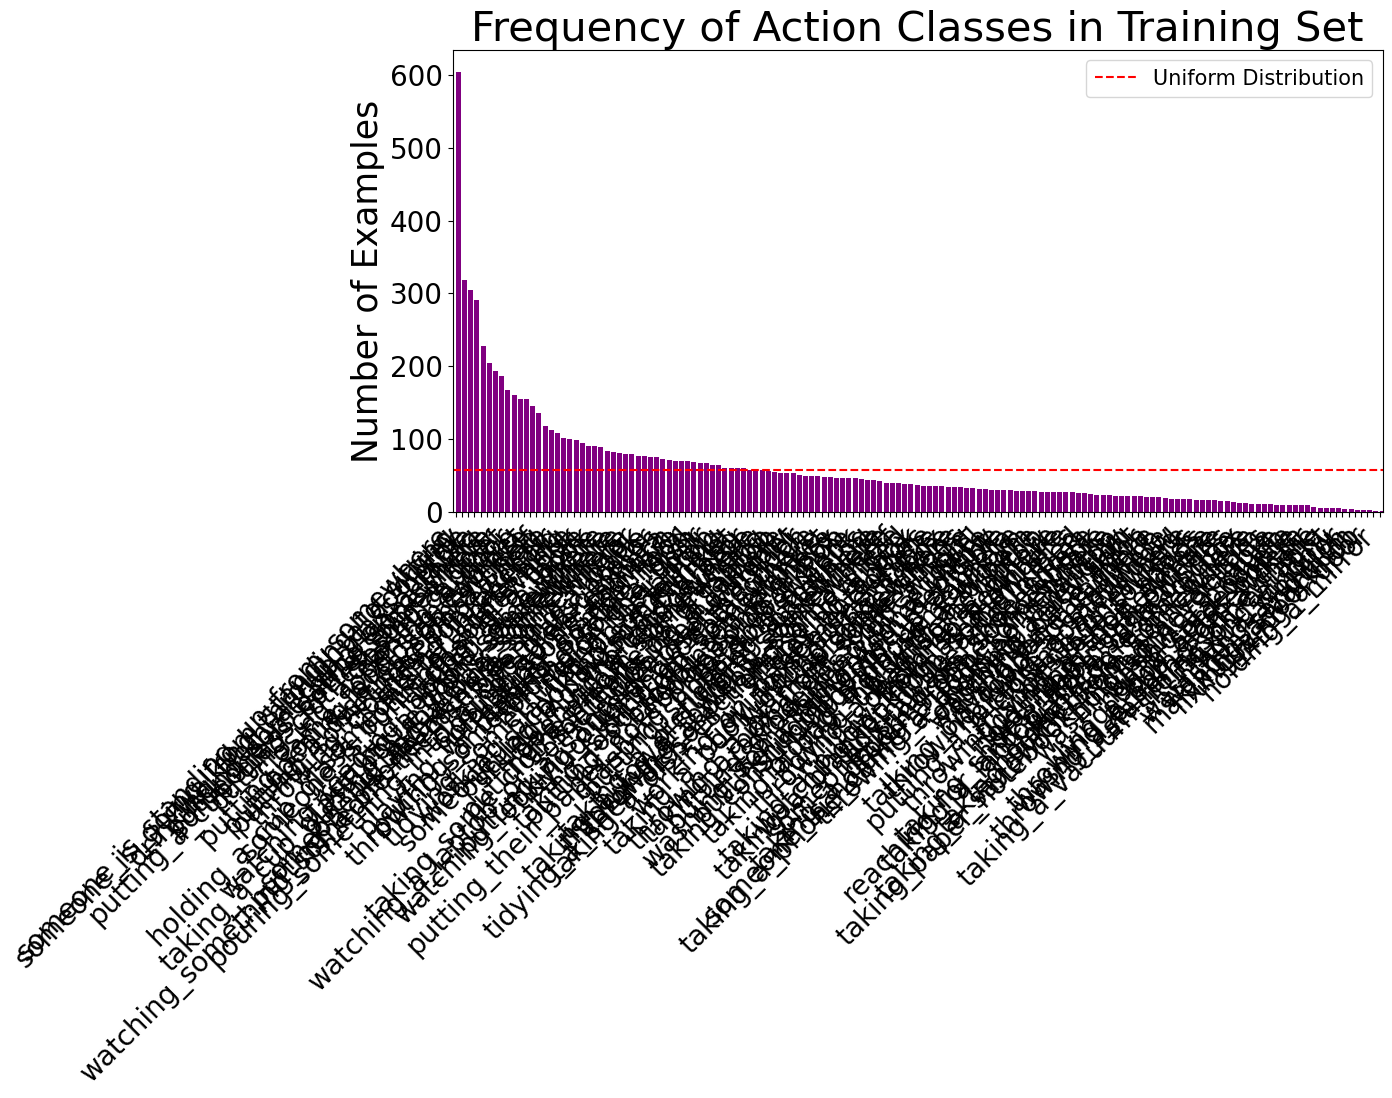

In [2]:
from util.rule_utils import normalize_predicate_name
rules_json_path = 'prolog/ag/pre/learned_rules/full_action_rules.json'
with open(rules_json_path, 'r') as file:
    rules_data = json.load(file)
rules_data = {normalize_predicate_name(key): value for key, value in rules_data.items()}

# Load the action priors from a checkpoint
checkpoint_path = 'runs/verbnoun_quick-architecture/checkpoints/epoch=16-val_acc=0.2283.ckpt'
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
classes = [normalize_predicate_name(c) for c in checkpoint['hyper_parameters']['classes']]
priors = checkpoint['hyper_parameters']['priors']

# Assuming the total number of examples in the data is the sum of priors
total_examples = 8693

# Calculate the number of examples for each verb class
counts = [prior * total_examples for prior in priors]

# Sort the verbs and counts from most to least
sorted_indices = sorted(range(len(counts)), key=lambda i: counts[i], reverse=True)
k = 75
rarest_k_indices = sorted_indices[:k]

# Print the action classes indices in sorted order
print("Sorted action class indices:", sorted_indices)
print("Sorted action class names:", [classes[i] for i in sorted_indices])
print("Percentage of total examples:", [f"{(counts[i] / total_examples) * 100:.2f}%" for i in sorted_indices])
print("Whether or not the class has no solution:", [(i, rules_data[classes[i]] is None) for i in sorted_indices])
print(sorted_indices[20])
print(classes[sorted_indices[20]])

# Plotting the histogram
sorted_classes = [classes[i] for i in sorted_indices]
sorted_counts = [counts[i] for i in sorted_indices]
plt.figure(figsize=(12, 6))
plt.bar(sorted_classes, sorted_counts, color='purple', align='edge')
plt.xlim(-0.5, len(sorted_classes) - 0.5)  # Adjust x-axis limits to remove space on the sides

# Calculate and draw the uniform distribution line
uniform_count = total_examples / len(classes)
plt.axhline(y=uniform_count, color='red', linestyle='--', label='Uniform Distribution')

plt.ylabel('Number of Examples', fontsize=25)
plt.title('Frequency of Action Classes in Training Set', fontsize=30)
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()


Loading dataset from cache: data/ag/cache/test_-1_aa93f8809d10d4dfc487662c5fccc648.pkl


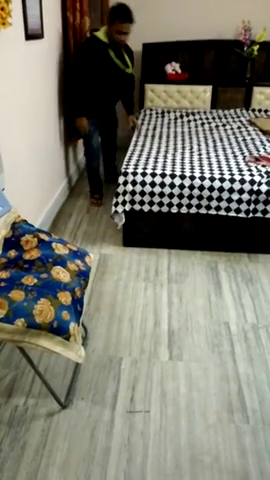

Putting a pillow somewhere


: 

In [ ]:
from data.ag.action_genome import SingleAG
from util.config_utils import load_yaml

cfg = load_yaml('configs/verbnoun.yaml')
dataset = SingleAG(cfg, split=cfg.test.data_split, no_img=False)

input = dataset[0]
truth = dataset.action_classes[int(input['action_label'])]
display(input['image'])
input['image'].save('test.png')

print(truth)